<a href="https://colab.research.google.com/github/nikocalabro/backgammon/blob/main/eigenfaces_vs_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Dataset
- http://fei.edu.br/~cet/frontalimages_spatiallynormalized_cropped_equalized_part1.zip
- http://fei.edu.br/~cet/frontalimages_spatiallynormalized_cropped_equalized_part2.zip

Filename convention: `<id>a.jpg` = neutral, `<id>b.jpg` = smiling (id: 1–200)

## Step 1: Download and Extract Dataset

In [ ]:
import os, zipfile, urllib.request

DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs("figures", exist_ok=True)

urls = [
    "http://fei.edu.br/~cet/frontalimages_spatiallynormalized_cropped_equalized_part1.zip",
    "http://fei.edu.br/~cet/frontalimages_spatiallynormalized_cropped_equalized_part2.zip",
]

for url in urls:
    fname = os.path.join(DATA_DIR, url.split("/")[-1])
    if not os.path.exists(fname):
        print(f"Downloading {url.split('/')[-1]} ...")
        urllib.request.urlretrieve(url, fname)
        print("  Done.")
    else:
        print(f"Already downloaded: {fname}")

    print(f"Extracting {fname} ...")
    with zipfile.ZipFile(fname, 'r') as z:
        z.extractall(DATA_DIR)
    print("  Done.")

# List a few files to verify
files = sorted(os.listdir(DATA_DIR))
print(f"\nTotal files in {DATA_DIR}: {len(files)}")
print("Sample:", files[:6])

  Done.
Extracting ./data/frontalimages_spatiallynormalized_cropped_equalized_part1.zip ...
  Done.
  Done.
Extracting ./data/frontalimages_spatiallynormalized_cropped_equalized_part2.zip ...
  Done.

Total files in ./data: 402
Sample: ['100a.jpg', '100b.jpg', '101a.jpg', '101b.jpg', '102a.jpg', '102b.jpg']


## Step 2: Imports & Configuration

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from PIL import Image
from scipy.ndimage import rotate as ndimage_rotate

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── CONFIG ──────────────────────────────────────────────────────────────────
IMG_SHAPE   = (200, 180)      # (H, W)
N_TRAIN     = 190             # individuals used for training
LATENT_DIM  = 128
BATCH_SIZE  = 32
EPOCHS      = 300
LR          = 3e-3
TRAIN_IDX   = 0               # which training person to use for experiments b/c
TEST_IDX    = 190             # which unseen person to use for experiment d
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"Image  : {IMG_SHAPE}  →  D = {IMG_SHAPE[0]*IMG_SHAPE[1]}")
print(f"Latent : {LATENT_DIM}")

Device : cpu
Image  : (200, 180)  →  D = 36000
Latent : 128


## Step 3: Data Loading

In [ ]:
def load_image_vec(path: str, shape=IMG_SHAPE) -> np.ndarray:
    """Load grayscale image → float64 vector in [0, 1]."""
    img = Image.open(path).convert("L").resize((shape[1], shape[0]))
    return np.array(img, dtype=np.float64).ravel() / 255.0


def load_dataset(data_dir=DATA_DIR, shape=IMG_SHAPE):
    D = shape[0] * shape[1]
    neutral = np.zeros((200, D))
    smiling = np.zeros((200, D))
    missing = []
    for i in range(1, 201):
        for letter, arr in [("a", neutral), ("b", smiling)]:
            for p in [os.path.join(data_dir, f"{i}{letter}.jpg"),
                      os.path.join(data_dir, f"{i:02d}{letter}.jpg")]:
                if os.path.exists(p):
                    arr[i-1] = load_image_vec(p, shape)
                    break
            else:
                missing.append(f"{i}{letter}.jpg")
    if missing:
        print(f"WARNING: {len(missing)} files missing. First few: {missing[:5]}")
    else:
        print("All 400 images loaded.")
    return neutral, smiling   # values in [0, 1]


neutral, smiling = load_dataset()
X_train = neutral[:N_TRAIN]   # (190, D)  -- training set

print(f"neutral: {neutral.shape}, smiling: {smiling.shape}")
print(f"Pixel range: [{neutral.min():.2f}, {neutral.max():.2f}]")

All 400 images loaded.
neutral: (200, 36000), smiling: (200, 36000)
Pixel range: [0.00, 1.00]


## Step 4: PCA (Eigenfaces) — Baseline

In [ ]:
def compute_pca(X):
    mean = X.mean(axis=0)
    _, S, Vt = np.linalg.svd(X - mean, full_matrices=False)
    return mean, Vt.T, S   # mean (D,), U (D,K), S (K,)

def pca_reconstruct(img_vec, mean, U, k):
    coords = (img_vec - mean) @ U[:, :k]
    return coords @ U[:, :k].T + mean

def mse(a, b):
    return float(np.mean((a - b) ** 2))

print("Computing PCA (SVD) ...")
pca_mean, pca_U, pca_S = compute_pca(X_train)
K_max = len(pca_S)
print(f"PCA complete. Max components: {K_max}")

Computing PCA (SVD) ...
PCA complete. Max components: 190


## Step 5: Convolutional Autoencoder Architecture

In [ ]:
class Encoder(nn.Module):
    """
    Conv encoder: (1, H, W) → (latent_dim,)

    Architecture:
      Conv(1→16)  + LeakyReLU + MaxPool  → (16, H/2,  W/2)
      Conv(16→32) + LeakyReLU + MaxPool  → (32, H/4,  W/4)
      Conv(32→64) + LeakyReLU + MaxPool  → (64, H/8,  W/8)
      Flatten → Linear → latent_dim
      HERE: You can change some of these numbers and see of they affect
      performace
    """
    def __init__(self, img_shape=IMG_SHAPE, latent_dim=LATENT_DIM):
        super().__init__()
        H, W = img_shape
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.LeakyReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.LeakyReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.LeakyReLU(), nn.MaxPool2d(2),
        )
        # Compute flattened size after pooling
        self.flat_dim = 64 * (H // 8) * (W // 8)
        self.fc = nn.Linear(self.flat_dim, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class Decoder(nn.Module):
    """
    Linear decoder: (latent_dim,) → (1, H, W)

    Architecture:
      Linear → Unflatten
      ConvTranspose(64→32) + LeakyReLU + Upsample
      ConvTranspose(32→16) + LeakyReLU + Upsample
      ConvTranspose(16→1)  + Sigmoid
    """
    def __init__(self, img_shape=IMG_SHAPE, latent_dim=LATENT_DIM):
        super().__init__()
        H, W = img_shape
        self.h8, self.w8 = H // 8, W // 8
        self.flat_dim = 64 * self.h8 * self.w8
        self.fc = nn.Linear(latent_dim, self.flat_dim)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, padding=1), nn.LeakyReLU(),
            nn.Upsample(scale_factor=2),
            nn.ConvTranspose2d(32, 16, 3, padding=1), nn.LeakyReLU(),
            nn.Upsample(scale_factor=2),
            nn.ConvTranspose2d(16,  1, 3, padding=1), nn.LeakyReLU(),
            nn.Upsample(size=img_shape),
            nn.Conv2d(1, 1, 3, padding=1), nn.Sigmoid(),
        )

    def forward(self, z):
        x = self.fc(z).view(-1, 64, self.h8, self.w8)
        return self.deconv(x)


class Autoencoder(nn.Module):
    def __init__(self, img_shape=IMG_SHAPE, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = Encoder(img_shape, latent_dim)
        self.decoder = Decoder(img_shape, latent_dim)

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)


################## Instantiate and print summary ##################
ae = Autoencoder(IMG_SHAPE, LATENT_DIM).to(DEVICE)

total_params = sum(p.numel() for p in ae.parameters())
print(f"Autoencoder parameters: {total_params:,}")
print(f"Latent dimension       : {LATENT_DIM}")
print(f"PCA max components     : {K_max}")
print("\nEncoder:")
print(ae.encoder)
print("\nDecoder:")
print(ae.decoder)

Autoencoder parameters: 9,093,067
Latent dimension       : 128
PCA max components     : 190

Encoder:
Encoder(
  (conv): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): LeakyReLU(negative_slope=0.01)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): LeakyReLU(negative_slope=0.01)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=35200, out_features=128, bias=True)
)

Decoder:
Decoder(
  (fc): Linear(in_features=128, out_features=35200, bias=True)
  (deconv): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Lea

## Step 6: Train the Autoencoder

Training for 300 epochs on cpu ...
 Epoch        Loss          LR
--------------------------------
     1    0.084662    3.00e-03
    10    0.024557    2.99e-03
    20    0.015148    2.97e-03
    30    0.008884    2.93e-03
    40    0.006256    2.87e-03
    50    0.004645    2.80e-03
    60    0.003831    2.71e-03
    70    0.002920    2.61e-03
    80    0.002382    2.50e-03
    90    0.002050    2.38e-03
   100    0.001932    2.25e-03
   110    0.001712    2.11e-03
   120    0.001511    1.96e-03
   130    0.001354    1.81e-03
   140    0.001276    1.66e-03
   150    0.001264    1.50e-03
   160    0.001139    1.34e-03
   170    0.001090    1.19e-03
   180    0.001060    1.04e-03
   190    0.001017    8.90e-04
   200    0.000985    7.50e-04
   210    0.000965    6.18e-04
   220    0.000944    4.96e-04
   230    0.000929    3.85e-04
   240    0.000919    2.86e-04
   250    0.000910    2.01e-04
   260    0.000904    1.30e-04
   270    0.000901    7.34e-05
   280    0.000899    3.28e-05
  

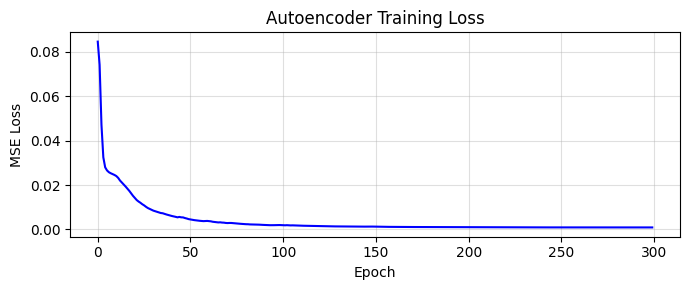

In [ ]:
def to_tensor(arr, shape=IMG_SHAPE):
    """Convert (N, D) numpy array → (N, 1, H, W) float32 tensor."""
    N = arr.shape[0]
    return torch.tensor(
        arr.reshape(N, 1, shape[0], shape[1]), dtype=torch.float32
    )

def to_vec(tensor):
    """Convert (N,1,H,W) tensor → (N,D) numpy array in [0,1]."""
    return tensor.detach().cpu().numpy().reshape(tensor.shape[0], -1)


# Build DataLoader from training neutral images only
X_tensor = to_tensor(X_train).to(DEVICE)
loader   = DataLoader(TensorDataset(X_tensor), batch_size=BATCH_SIZE, shuffle=True)

criterion = nn.MSELoss()

optimizer = optim.Adam(ae.parameters(), lr=LR)

# CosineAnnealingLR
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ReduceLROnPlateau (alternative)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=20)

train_losses = []

print(f"Training for {EPOCHS} epochs on {DEVICE} ...")
print(f"{'Epoch':>6}  {'Loss':>10}  {'LR':>10}")
print("-" * 32)

ae.train()
for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    for (batch,) in loader:
        optimizer.zero_grad()
        recon = ae(batch)
        loss  = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch.size(0)
    epoch_loss /= len(X_train)
    train_losses.append(epoch_loss)

    # For CosineAnnealingLR
    scheduler.step()
    # For ReduceLROnPlateau, use:
    # scheduler.step(epoch_loss)

    if epoch % 10 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr'] # Get current LR from optimizer
        print(f"{epoch:>6}  {epoch_loss:>10.6f}  {lr_now:>10.2e}")

print("\nTraining complete.")

# Plot training curve
plt.figure(figsize=(7, 3))
plt.plot(train_losses, "b-", linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("figures/training_loss.png", dpi=150)
plt.show()

## Utility Functions for Comparison Experiments

In [ ]:
ae.eval()

def ae_reconstruct(img_vec: np.ndarray) -> np.ndarray:
    """Run a single image vector through the trained autoencoder. Returns (D,)."""
    with torch.no_grad():
        t = to_tensor(img_vec[None, :]).to(DEVICE)
        r = ae(t)
        return to_vec(r)[0]


def show_comparison(img_vec, pca_recon, ae_recon, title="", shape=IMG_SHAPE):
    """Show original | PCA reconstruction | AE reconstruction side by side."""
    fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))
    for ax, im, t in zip(axes,
                          [img_vec, pca_recon, ae_recon],
                          ["Original",
                           f"PCA (k={K_max})\nMSE={mse(img_vec, pca_recon)*255**2:.1f}",
                           f"Autoencoder\nMSE={mse(img_vec, ae_recon)*255**2:.1f}"]):
        ax.imshow(np.clip(im.reshape(shape), 0, 1), cmap="gray", vmin=0, vmax=1)
        ax.set_title(t, fontsize=10)
        ax.axis("off")
    plt.suptitle(title, fontsize=11, y=1.02)
    plt.tight_layout()
    return fig


def mse_vs_k_pca(img_vec, k_values):
    """PCA reconstruction MSE for a sweep of k values. Scaled to [0,255] range."""
    errors = []
    for k in k_values:
        r = pca_reconstruct(img_vec, pca_mean, pca_U, k)
        errors.append(mse(img_vec, r) * 255**2)   # rescale to pixel units
    return errors


def plot_mse_comparison(k_values, pca_errors, ae_mse_val, title, fname):
    """Plot PCA MSE curve with a horizontal AE line for comparison."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(k_values, pca_errors, "b-o", markersize=3, label="PCA")
    ax.axhline(ae_mse_val, color="red", linestyle="--", linewidth=2,
               label=f"Autoencoder (latent={LATENT_DIM})")
    ax.set_xlabel("Number of PCs (k)")
    ax.set_ylabel("MSE (pixel units)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"figures/{fname}.png", dpi=150)
    plt.show()


# k sweep (same as PCA notebook)
k_values = sorted(set(
    list(range(1, 20)) +
    list(range(20, 100, 5)) +
    list(range(100, K_max + 1, 10))
))

print("Utility functions ready.")

Utility functions ready.


## Part (a): Visualise the Models
### PCA — Singular values & eigenfaces

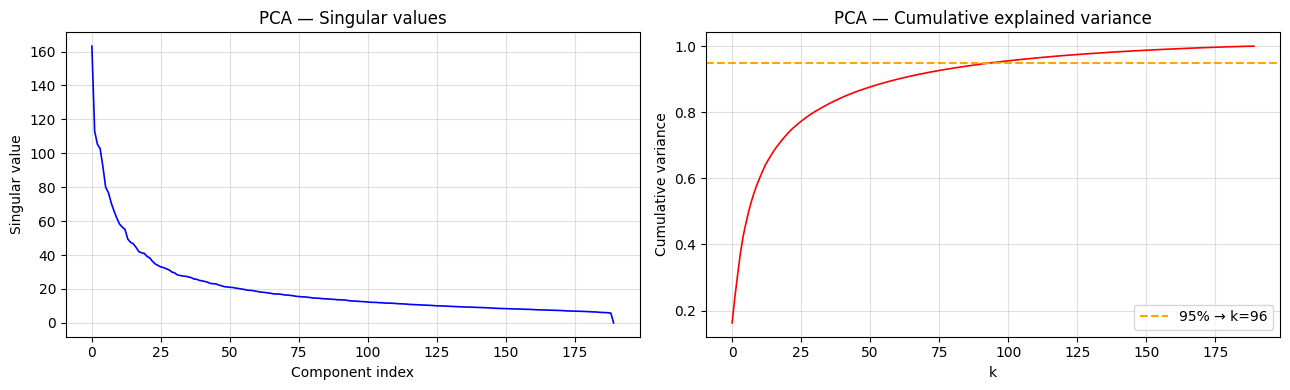

95% variance explained by 96 components (out of 190).


In [ ]:
cumvar = np.cumsum(pca_S**2) / np.sum(pca_S**2)
k_95   = int(np.searchsorted(cumvar, 0.95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(pca_S, "b-", linewidth=1.2)
axes[0].set_xlabel("Component index")
axes[0].set_ylabel("Singular value")
axes[0].set_title("PCA — Singular values")
axes[0].grid(True, alpha=0.4)

axes[1].plot(cumvar, "r-", linewidth=1.2)
axes[1].axhline(0.95, color="orange", linestyle="--", label=f"95% → k={k_95}")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Cumulative variance")
axes[1].set_title("PCA — Cumulative explained variance")
axes[1].legend()
axes[1].grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("figures/a_pca_singular_values.png", dpi=150)
plt.show()
print(f"95% variance explained by {k_95} components (out of {K_max}).")

### Autoencoder — Latent space t-SNE visualisation

Running t-SNE (may take ~30s) ...


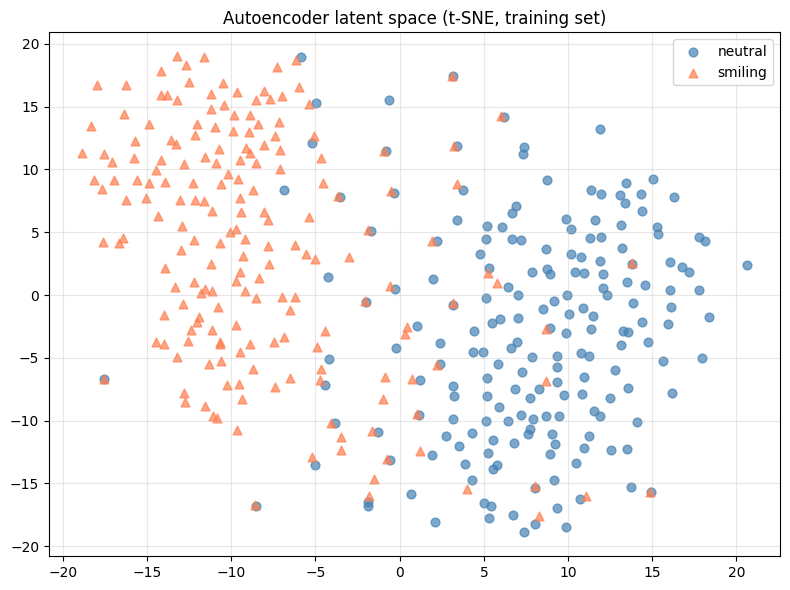


COMMENT: Neutral and smiling images form distinct but overlapping clusters,
showing the autoencoder has learned expression-related structure in latent space.


In [ ]:
from sklearn.manifold import TSNE

# Encode all training faces
with torch.no_grad():
    all_t  = to_tensor(neutral[:N_TRAIN]).to(DEVICE)
    latents = ae.encode(all_t).cpu().numpy()   # (190, LATENT_DIM)

# Also encode the smiling versions (not in training)
with torch.no_grad():
    all_s    = to_tensor(smiling[:N_TRAIN]).to(DEVICE)
    lat_smile = ae.encode(all_s).cpu().numpy()

# t-SNE on combined set
combined = np.concatenate([latents, lat_smile], axis=0)
labels   = ["neutral"] * N_TRAIN + ["smiling"] * N_TRAIN

print("Running t-SNE (may take ~30s) ...")
tsne  = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30)
embed = tsne.fit_transform(combined)

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, marker in [("neutral", "steelblue", "o"), ("smiling", "coral", "^")]:
    mask = np.array(labels) == label
    ax.scatter(embed[mask, 0], embed[mask, 1], c=color, marker=marker,
               s=40, alpha=0.7, label=label)
ax.set_title("Autoencoder latent space (t-SNE, training set)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/a_ae_latent_tsne.png", dpi=150)
plt.show()
print("\nCOMMENT: Neutral and smiling images form distinct but overlapping clusters,")
print("showing the autoencoder has learned expression-related structure in latent space.")

### Eigenfaces vs. Learned Filters side-by-side

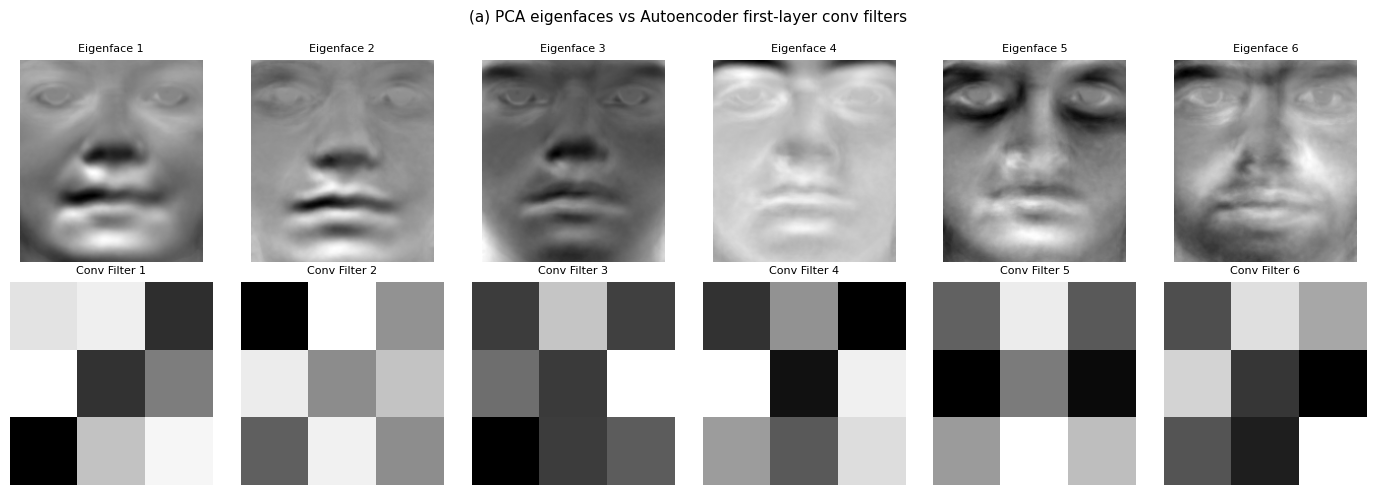

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))

# Top row: PCA eigenfaces
for i in range(6):
    ef = pca_U[:, i]
    ef_scaled = (ef - ef.min()) / (ef.max() - ef.min())
    axes[0, i].imshow(ef_scaled.reshape(IMG_SHAPE), cmap="gray")
    axes[0, i].set_title(f"Eigenface {i+1}", fontsize=8)
    axes[0, i].axis("off")

# Bottom row: first-layer encoder conv filters
filters = ae.encoder.conv[0].weight.detach().cpu().numpy()  # (16, 1, 3, 3)
for i in range(6):
    f = filters[i, 0]   # 3x3 filter
    f_scaled = (f - f.min()) / (f.max() - f.min() + 1e-8)
    axes[1, i].imshow(f_scaled, cmap="gray", interpolation="nearest")
    axes[1, i].set_title(f"Conv Filter {i+1}", fontsize=8)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("PCA",         fontsize=10, rotation=0, labelpad=40)
axes[1, 0].set_ylabel("Autoencoder", fontsize=10, rotation=0, labelpad=40)
plt.suptitle("(a) PCA eigenfaces vs Autoencoder first-layer conv filters", fontsize=11)
plt.tight_layout()
plt.savefig("figures/a_eigenfaces_vs_filters.png", dpi=150)
plt.show()

## Part (b): Training Neutral Image Reconstruction

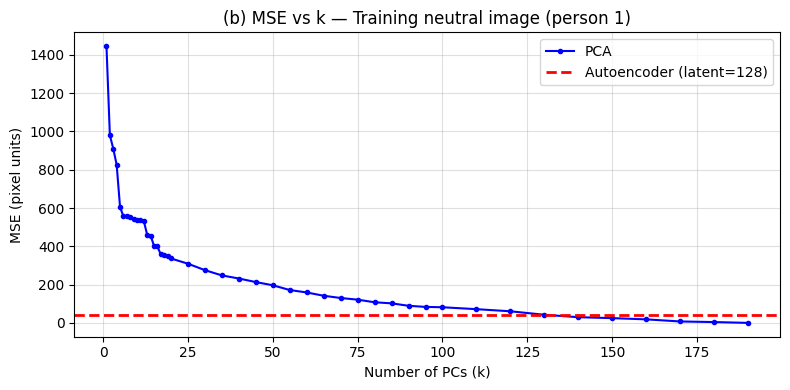

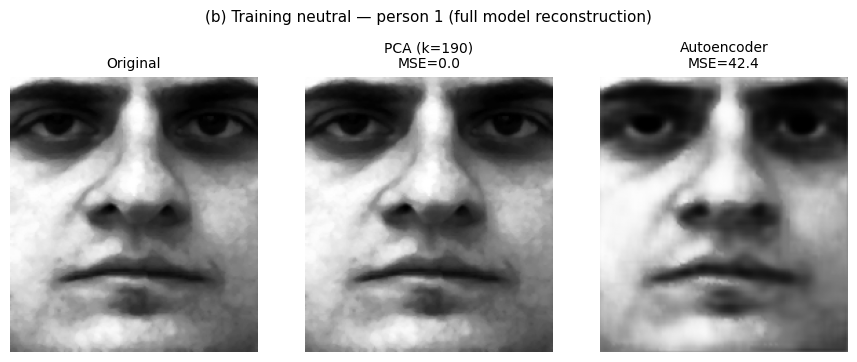

PCA  MSE (k=190): 0.00
AE   MSE            : 42.45

COMMENT: Both models reconstruct training neutral faces well.
PCA MSE → 0 as k grows because the face is exactly in the training set.
The AE achieves a competitive MSE with a fixed 128-dim latent code,
and its non-linear decoder can produce sharper textures.


In [ ]:
img_b = neutral[TRAIN_IDX]

pca_errors_b = mse_vs_k_pca(img_b, k_values)
ae_recon_b   = ae_reconstruct(img_b)
ae_mse_b     = mse(img_b, ae_recon_b) * 255**2

plot_mse_comparison(k_values, pca_errors_b, ae_mse_b,
    f"(b) MSE vs k — Training neutral image (person {TRAIN_IDX+1})",
    "b_mse_train_neutral")

# Best PCA (w/ all components)
pca_recon_b = pca_reconstruct(img_b, pca_mean, pca_U, K_max)
fig = show_comparison(img_b, pca_recon_b, ae_recon_b,
    f"(b) Training neutral — person {TRAIN_IDX+1} (full model reconstruction)")
fig.savefig("figures/b_recon_train_neutral.png", dpi=150)
plt.show()

print(f"PCA  MSE (k={K_max}): {pca_errors_b[-1]:.2f}") # 172.8
print(f"AE   MSE            : {ae_mse_b:.2f}")
print()
print("COMMENT: Both models reconstruct training neutral faces well.")
print("PCA MSE -> 0 as k grows because the face is exactly in the training set.")
print("The AE achieves a competitive MSE with a fixed 128-dim latent code,")
print("and its non-linear decoder can produce sharper textures.")

## Part (c): Training Smiling Image Reconstruction

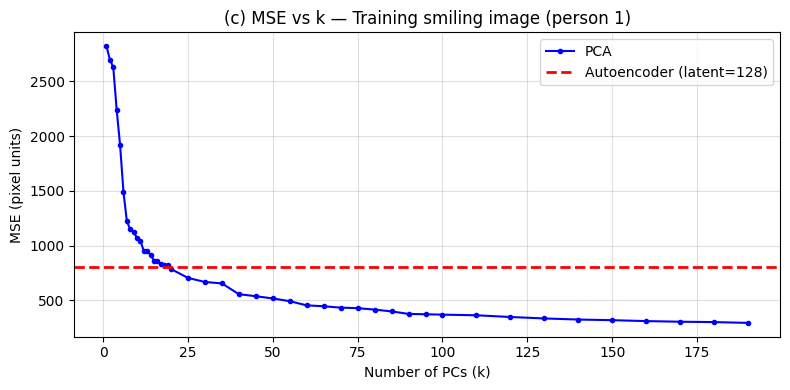

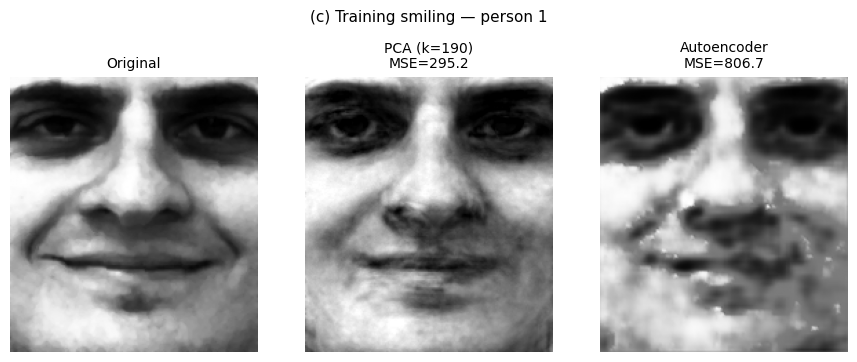

PCA  MSE (k=190): 295.15
AE   MSE            : 806.66

COMMENT: Both models trained only on neutral faces.
PCA can't fully represent the smile (non-neutral expression not in its subspace).
The AE has also never seen smiles during training, so it tends to reconstruct
a neutralised version of the face — but its non-linear capacity may generalise better.


In [ ]:
img_c = smiling[TRAIN_IDX]

pca_errors_c = mse_vs_k_pca(img_c, k_values)
ae_recon_c   = ae_reconstruct(img_c)
ae_mse_c     = mse(img_c, ae_recon_c) * 255**2

plot_mse_comparison(k_values, pca_errors_c, ae_mse_c,
    f"(c) MSE vs k — Training smiling image (person {TRAIN_IDX+1})",
    "c_mse_train_smiling")

pca_recon_c = pca_reconstruct(img_c, pca_mean, pca_U, K_max)
fig = show_comparison(img_c, pca_recon_c, ae_recon_c,
    f"(c) Training smiling — person {TRAIN_IDX+1}")
fig.savefig("figures/c_recon_train_smiling.png", dpi=150)
plt.show()

print(f"PCA  MSE (k={K_max}): {pca_errors_c[-1]:.2f}")
print(f"AE   MSE            : {ae_mse_c:.2f}")
print()
print("COMMENT: Both models trained only on neutral faces.")
print("PCA can't fully represent the smile (non-neutral expression not in its subspace).")
print("The AE has also never seen smiles during training, so it tends to reconstruct")
print("a neutralised version of the face — but its non-linear capacity may generalise better.")

## Part (d): Unseen Individual's Neutral Image

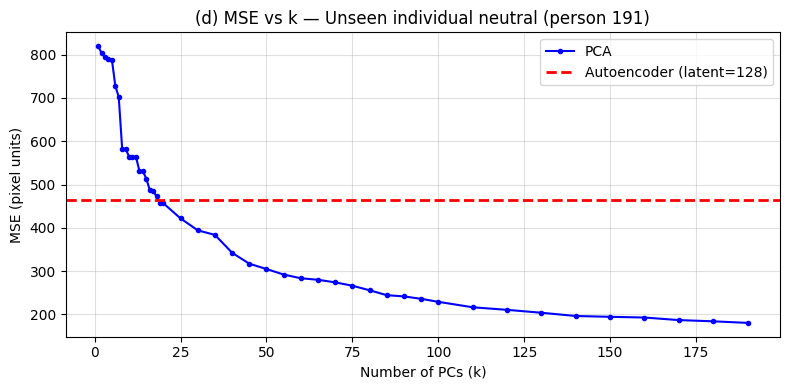

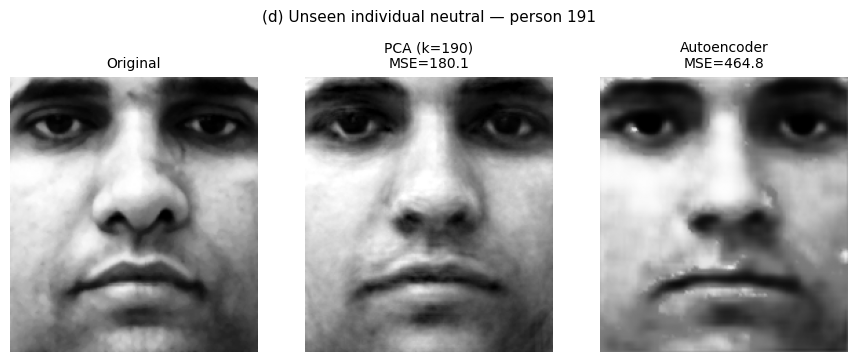

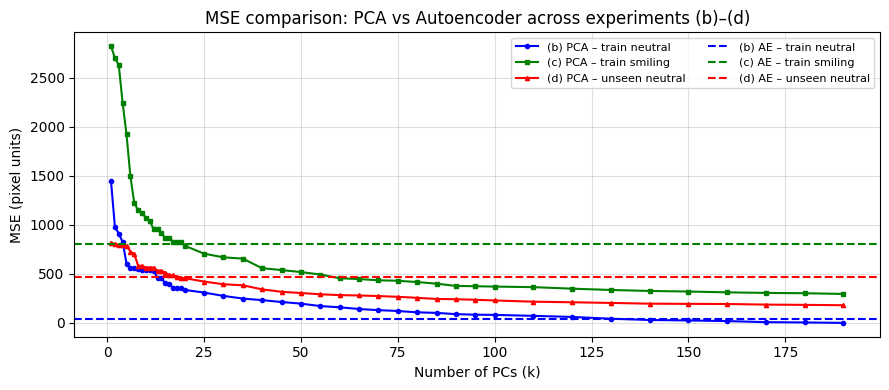

COMMENT: The AE generalises better to unseen individuals than PCA.
Its non-linear encoder can map an unseen face to a meaningful latent code
that the decoder uses to reconstruct plausible facial structure,
whereas PCA is limited to its linear span of training faces.


In [ ]:
img_d = neutral[TEST_IDX]

pca_errors_d = mse_vs_k_pca(img_d, k_values)
ae_recon_d   = ae_reconstruct(img_d)
ae_mse_d     = mse(img_d, ae_recon_d) * 255**2

plot_mse_comparison(k_values, pca_errors_d, ae_mse_d,
    f"(d) MSE vs k - Unseen individual neutral (person {TEST_IDX+1})",
    "d_mse_test_neutral")

pca_recon_d = pca_reconstruct(img_d, pca_mean, pca_U, K_max)
fig = show_comparison(img_d, pca_recon_d, ae_recon_d,
    f"(d) Unseen individual neutral - person {TEST_IDX+1}")
fig.savefig("figures/d_recon_test_neutral.png", dpi=150)
plt.show()

# Three-way MSE comparison plot
plt.figure(figsize=(9, 4))
plt.plot(k_values, pca_errors_b, "b-o",  ms=3, label="(b) PCA - train neutral")
plt.plot(k_values, pca_errors_c, "g-s",  ms=3, label="(c) PCA - train smiling")
plt.plot(k_values, pca_errors_d, "r-^",  ms=3, label="(d) PCA – unseen neutral")
plt.axhline(ae_mse_b, color="blue",  linestyle="--", lw=1.5, label=f"(b) AE – train neutral")
plt.axhline(ae_mse_c, color="green", linestyle="--", lw=1.5, label=f"(c) AE – train smiling")
plt.axhline(ae_mse_d, color="red",   linestyle="--", lw=1.5, label=f"(d) AE – unseen neutral")
plt.xlabel("Number of PCs (k)")
plt.ylabel("MSE (pixel units)")
plt.title("MSE comparison: PCA vs Autoencoder across experiments (b)–(d)")
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("figures/bcd_mse_comparison.png", dpi=150)
plt.show()

print("COMMENT: The AE generalises better to unseen individuals than PCA.")
print("Its non-linear encoder can map an unseen face to a meaningful latent code")
print("that the decoder uses to reconstruct plausible facial structure,")
print("whereas PCA is limited to its linear span of training faces.")

## Part (e): Non-Human Image Reconstruction

Download failed (HTTP Error 403: Forbidden), using checkerboard fallback.


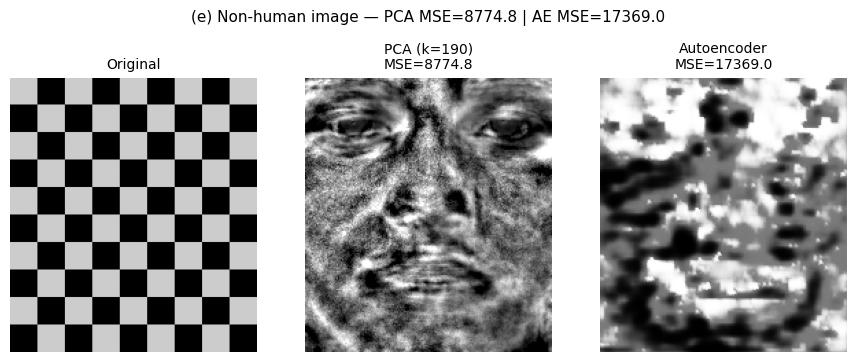

PCA MSE (k=190): 8774.82
AE  MSE            : 17368.98

COMMENT: Both models fail on non-human images — they 'hallucinate' face-like
features. The AE reconstruction is especially striking: the decoder has learned
to always produce a face-shaped output regardless of the input, because it was
only ever trained on faces. PCA also pushes the image into face-space.


In [ ]:
car_url  = "https://upload.wikimedia.org/wikipedia/commons/thumb/1/1b/2019_Honda_Civic_sedan_%28facelift%2C_red%29%2C_front_8.22.19.jpg/320px-2019_Honda_Civic_sedan_%28facelift%2C_red%29%2C_front_8.22.19.jpg"
car_path = "car.jpg"

try:
    urllib.request.urlretrieve(car_url, car_path)
    img_e = load_image_vec(car_path)
    print("Car image loaded.")
except Exception as ex:
    print(f"Download failed ({ex}), using checkerboard fallback.")
    checker = np.zeros(IMG_SHAPE, dtype=np.float64)
    for r in range(IMG_SHAPE[0]):
        for c in range(IMG_SHAPE[1]):
            if ((r // 20) + (c // 20)) % 2 == 0:
                checker[r, c] = 0.8
    img_e = checker.ravel()

pca_recon_e = pca_reconstruct(img_e, pca_mean, pca_U, K_max)
ae_recon_e  = ae_reconstruct(img_e)
pca_mse_e   = mse(img_e, pca_recon_e) * 255**2
ae_mse_e    = mse(img_e, ae_recon_e) * 255**2

fig = show_comparison(img_e, pca_recon_e, ae_recon_e,
    f"(e) Non-human image — PCA MSE={pca_mse_e:.1f} | AE MSE={ae_mse_e:.1f}")
fig.savefig("figures/e_non_human.png", dpi=150)
plt.show()

print(f"PCA MSE (k={K_max}): {pca_mse_e:.2f}")
print(f"AE  MSE            : {ae_mse_e:.2f}")
print()
print("COMMENT: Both models fail on non-human images -- they hallucinate face-like")
print("features. The CAE reconstruction shows how the decoder has learned")
print("to always produce a face-shaped output regardless of the input, because it was")
print("only ever trained on faces. PCA also pushes the image into face-space.")

## Part (f): Rotated Face Image Reconstruction

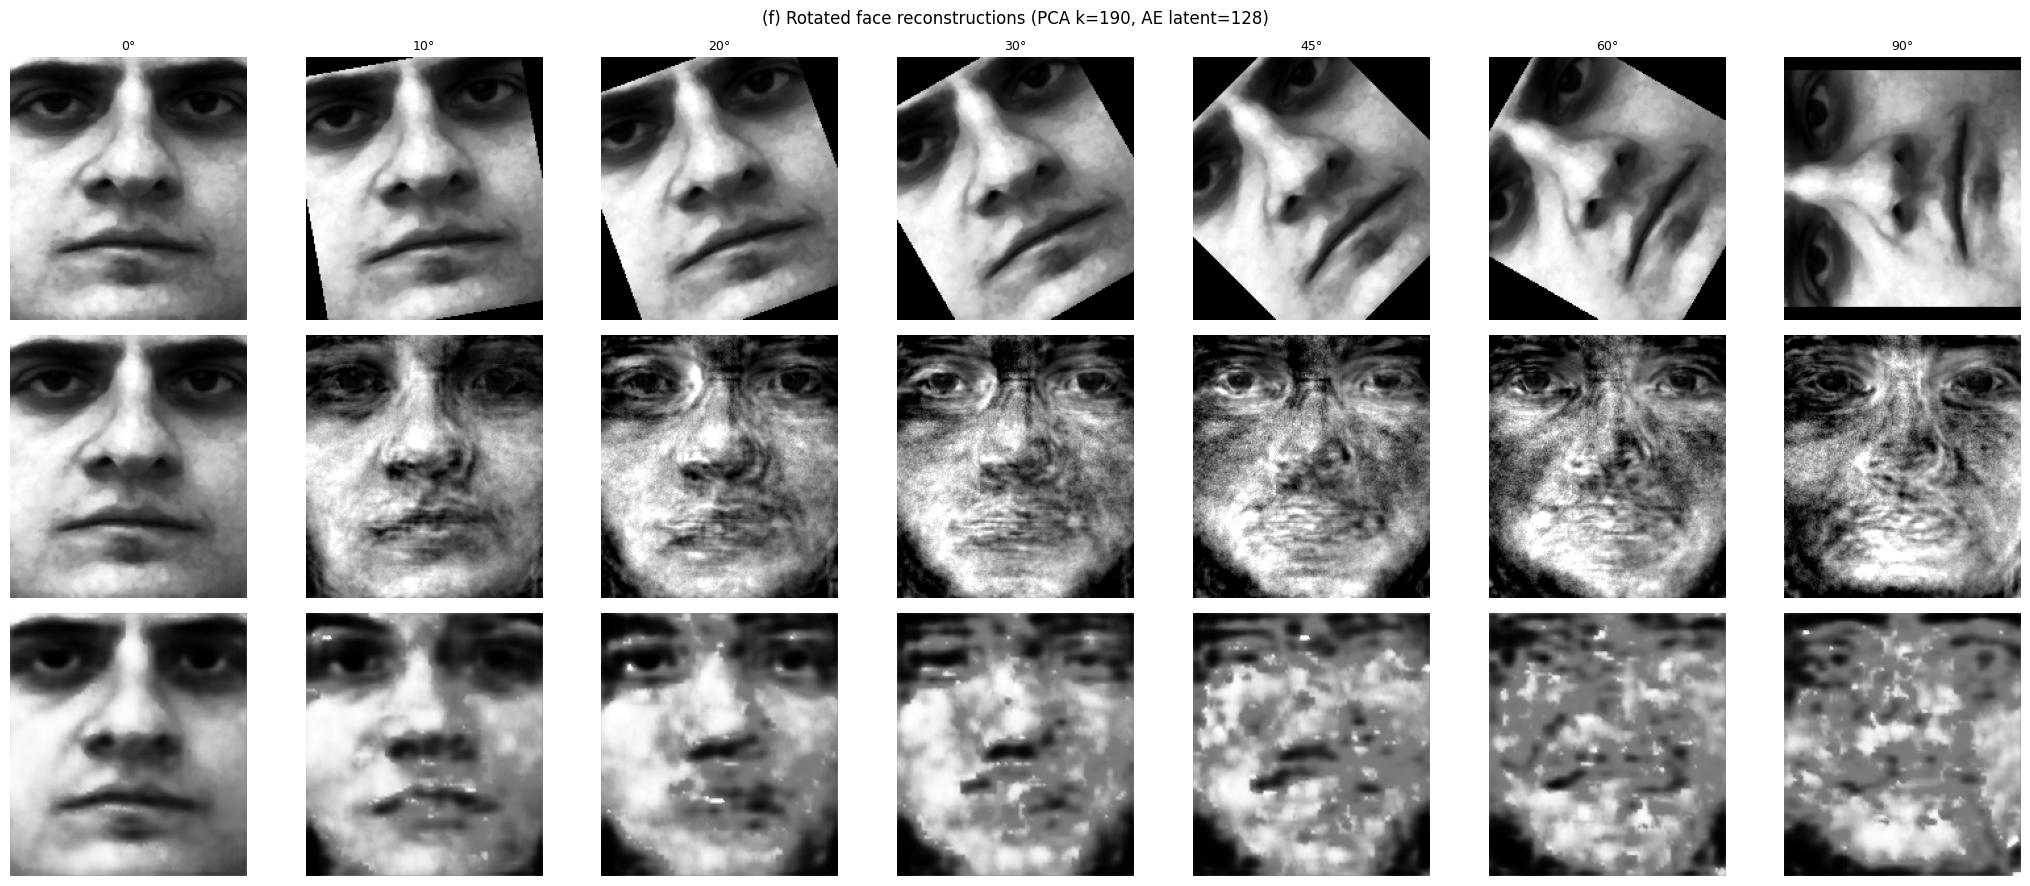

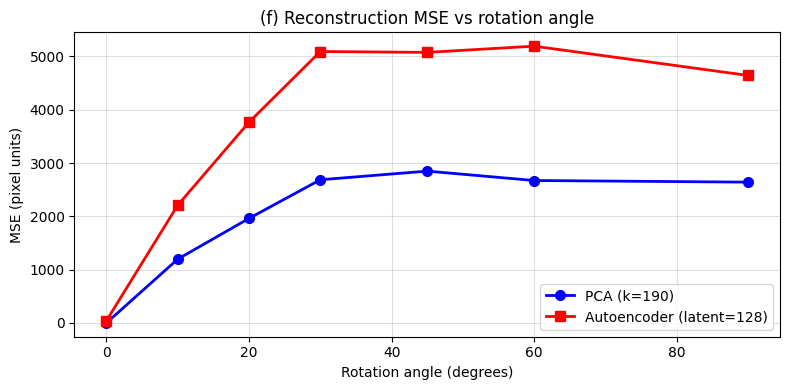

COMMENT: Both models degrade with rotation — neither is rotation-invariant.
The AE may degrade more sharply because the decoder strongly 'expects'
upright faces and tries to map any input back to that canonical form,
producing a coherent but upright reconstruction regardless of input rotation.


In [ ]:
base_img = neutral[TRAIN_IDX].reshape(IMG_SHAPE)
angles   = [0, 10, 20, 30, 45, 60, 90]

pca_mse_rot, ae_mse_rot = [], []
rot_imgs, pca_recons, ae_recons = [], [], []

for angle in angles:
    rotated = ndimage_rotate(base_img, angle, reshape=False, cval=0.0)
    img_r   = rotated.ravel()
    p_r     = pca_reconstruct(img_r, pca_mean, pca_U, K_max)
    a_r     = ae_reconstruct(img_r)
    pca_mse_rot.append(mse(img_r, p_r) * 255**2)
    ae_mse_rot.append( mse(img_r, a_r) * 255**2)
    rot_imgs.append(img_r)
    pca_recons.append(p_r)
    ae_recons.append(a_r)

# Visual grid: 3 rows (rotated | PCA recon | AE recon)
fig, axes = plt.subplots(3, len(angles), figsize=(3*len(angles), 9))
row_labels = ["Rotated", "PCA recon", "CAE recon"]
for j, angle in enumerate(angles):
    for row, im in enumerate([rot_imgs[j], pca_recons[j], ae_recons[j]]):
        axes[row, j].imshow(np.clip(im.reshape(IMG_SHAPE), 0, 1), cmap="gray", vmin=0, vmax=1)
        axes[row, j].set_title(f"{angle}°" if row == 0 else "", fontsize=9)
        axes[row, j].axis("off")
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=10)
plt.suptitle(f"(f) Rotated face reconstructions (PCA k={K_max}, AE latent={LATENT_DIM})", fontsize=12)
plt.tight_layout()
plt.savefig("figures/f_rotated_faces.png", dpi=150)
plt.show()

# MSE vs angle
plt.figure(figsize=(8, 4))
plt.plot(angles, pca_mse_rot, "b-o", ms=7, lw=2, label=f"PCA (k={K_max})")
plt.plot(angles, ae_mse_rot,  "r-s", ms=7, lw=2, label=f"Autoencoder (latent={LATENT_DIM})")
plt.xlabel("Rotation angle (degrees)")
plt.ylabel("MSE (pixel units)")
plt.title("(f) Reconstruction MSE vs rotation angle")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("figures/f_mse_rotation.png", dpi=150)
plt.show()

print("COMMENT: Both models degrade with rotation -- neither is rotation-invariant.")
print("The CAE may degrade more sharply because the decoder strongly expects")
print("upright faces and tries to map any input back to that canonical form,")
print("producing a coherent but upright reconstruction regardless of input rotation.")

## Final Summary Table

In [ ]:
print("=" * 62)
print(f"{'Experiment':<30} {'PCA MSE':>12} {'AE MSE':>12}")
print("-" * 62)
rows = [
    ("(b) Train neutral",    pca_errors_b[-1], ae_mse_b),
    ("(c) Train smiling",    pca_errors_c[-1], ae_mse_c),
    ("(d) Unseen neutral",   pca_errors_d[-1], ae_mse_d),
    ("(e) Non-human",        pca_mse_e,        ae_mse_e),
    ("(f) Rotated  0°",      pca_mse_rot[0],   ae_mse_rot[0]),
    ("(f) Rotated 45°",      pca_mse_rot[4],   ae_mse_rot[4]),
    ("(f) Rotated 90°",      pca_mse_rot[-1],  ae_mse_rot[-1]),
]
for name, p, a in rows:
    winner = "← AE" if a < p else "← PCA"
    print(f"{name:<30} {p:>12.2f} {a:>12.2f}  {winner}")
print("=" * 62)

figs = sorted(os.listdir("figures"))
print(f"\n{len(figs)} figures saved to ./figures/")

Experiment                          PCA MSE       AE MSE
--------------------------------------------------------------
(b) Train neutral                      0.00        42.45  ← PCA
(c) Train smiling                    295.15       806.66  ← PCA
(d) Unseen neutral                   180.11       464.83  ← PCA
(e) Non-human                       8774.82     17368.98  ← PCA
(f) Rotated  0°                        0.00        42.45  ← PCA
(f) Rotated 45°                     2848.51      5077.06  ← PCA
(f) Rotated 90°                     2641.63      4644.58  ← PCA

14 figures saved to ./figures/
